# Ecommerce Customers Lab 



## 1. Import libraries and load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load dataset
df = pd.read_csv('Ecommerce Customers')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 2. Explore the data

In [2]:
# First 5 rows
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
# Statistical summary
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
# Check column names
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

## 3. Basic data cleaning

We will check for:
- missing values
- duplicate rows
- incorrect data types

If any issue appears, we will fix it.


In [6]:
# Missing values
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [7]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Remove duplicates if any
df = df.drop_duplicates().copy()

# Confirm shape after cleaning
df.shape

(500, 8)

## 4. Feature engineering

The dataset contains text columns such as **Email**, **Address**, and **Avatar**.  
Since Linear Regression requires numeric inputs, we will:
- keep the main numeric features from the lab-style workflow
- create one simple engineered feature: **App_Website_Ratio**

This feature compares how much time a customer spends on the mobile app relative to the website.


In [9]:
# Create a simple engineered feature
df['App_Website_Ratio'] = df['Time on App'] / df['Time on Website']

# Preview
df[['Time on App', 'Time on Website', 'App_Website_Ratio']].head()

,Time on App,Time on Website,App_Website_Ratio
0,12.655651,39.577668,0.319767
1,11.109461,37.268959,0.298089
2,11.330278,37.110597,0.305311
3,13.717514,36.721283,0.373558
4,12.795189,37.536653,0.340872


## 5. Exploratory Data Analysis (optional but useful)

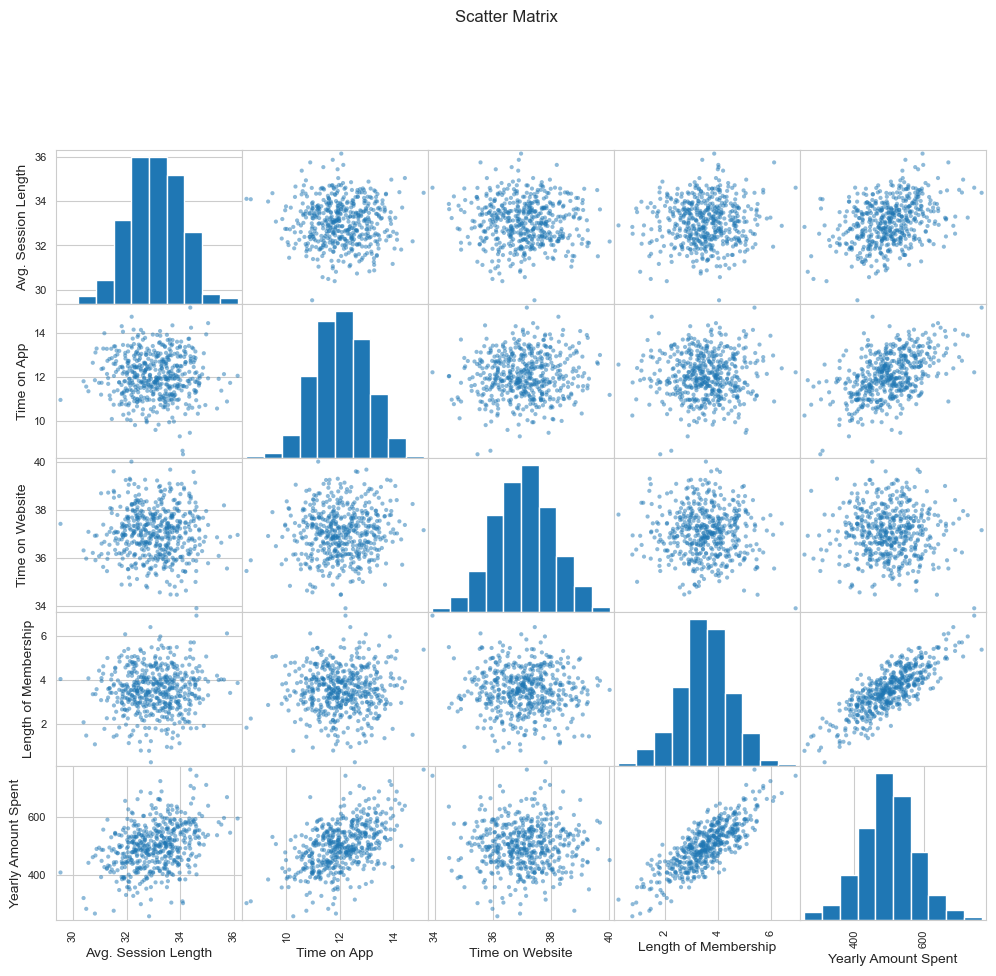

In [10]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[['Avg. Session Length', 'Time on App', 'Time on Website',
        'Length of Membership', 'Yearly Amount Spent']],
    figsize=(12, 10),
    diagonal='hist'
)
plt.suptitle('Scatter Matrix', y=1.02)
plt.show()

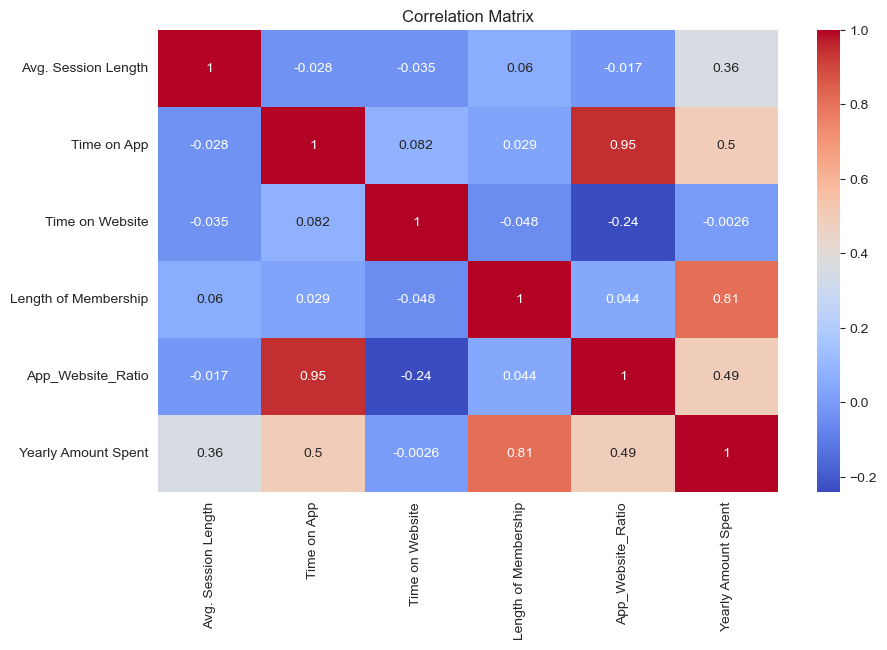

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Avg. Session Length', 'Time on App', 'Time on Website',
                'Length of Membership', 'App_Website_Ratio',
                'Yearly Amount Spent']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6. Prepare the data for modeling

Target variable:
- **Yearly Amount Spent**

Feature columns:
- Avg. Session Length
- Time on App
- Time on Website
- Length of Membership
- App_Website_Ratio


In [12]:
X = df[['Avg. Session Length', 'Time on App',
         'Time on Website', 'Length of Membership', 'App_Website_Ratio']]

y = df['Yearly Amount Spent']

X.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,App_Website_Ratio
0,34.497268,12.655651,39.577668,4.082621,0.319767
1,31.926272,11.109461,37.268959,2.664034,0.298089
2,33.000915,11.330278,37.110597,4.104543,0.305311
3,34.305557,13.717514,36.721283,3.120179,0.373558
4,33.330673,12.795189,37.536653,4.446308,0.340872


## 7. Train-test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (300, 5)
X_test shape: (200, 5)
y_train shape: (300,)
y_test shape: (200,)


## 8. Train the model

Using the **same model as the lab**: `LinearRegression`


In [14]:
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Intercept
print('Intercept:', lm.intercept_)

Intercept: -1243.3369255471919


In [16]:
# Coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lm.coef_
})
coeff_df

,Feature,Coefficient
0,Avg. Session Length,25.709202
1,Time on App,21.460255
2,Time on Website,5.894653
3,Length of Membership,61.667307
4,App_Website_Ratio,608.374891


## 9. Make predictions

In [17]:
predictions = lm.predict(X_test)
predictions[:10]

array([453.02847493, 406.61159386, 411.15918744, 590.99132945,
       590.36657372, 548.20632982, 577.5759521 , 713.66279542,
       472.95503147, 546.06191282])

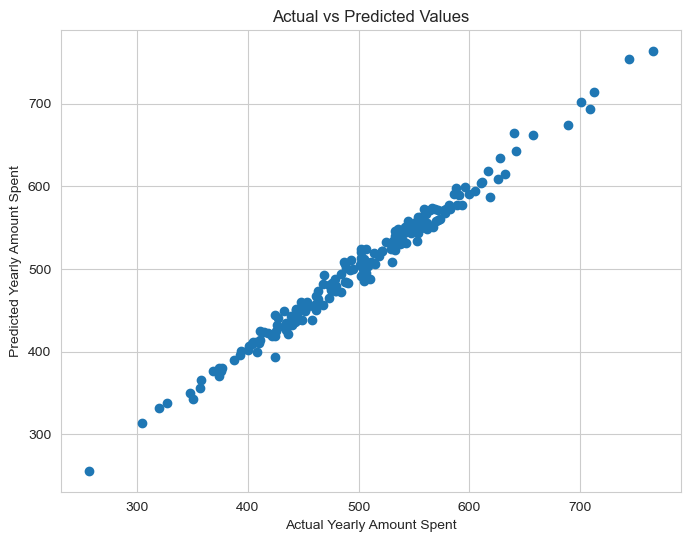

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted Values')
plt.show()

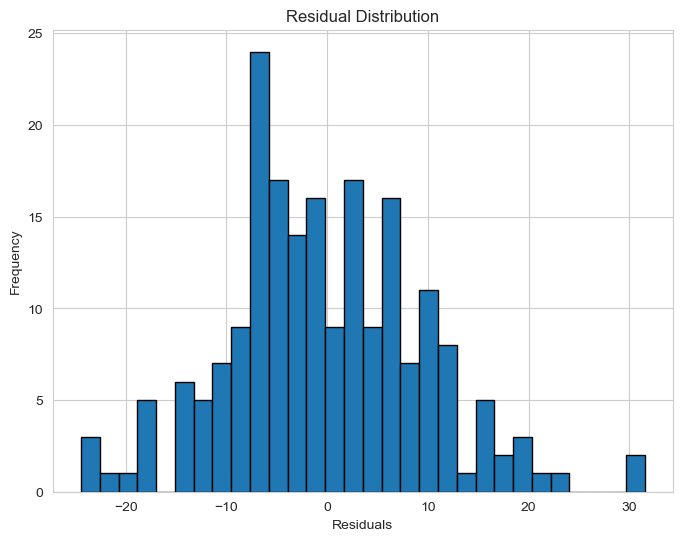

In [19]:
plt.figure(figsize=(8,6))
plt.hist((y_test - predictions), bins=30, edgecolor='black')
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

## 10. Evaluate the model performance

In [20]:
print('MAE :', metrics.mean_absolute_error(y_test, predictions))
print('MSE :', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2  :', metrics.r2_score(y_test, predictions))

MAE : 7.692425769805983
MSE : 93.4636026943698
RMSE: 9.667657559841981
R2  : 0.9855631794227334


## 11. Conclusion

- The dataset was loaded and explored successfully.
- Basic cleaning showed no major issues.
- A simple engineered feature (**App_Website_Ratio**) was added.
- The data was prepared and split into training and testing sets.
- A **Linear Regression** model was trained, matching the lab approach.
- The model achieved strong performance for predicting **Yearly Amount Spent**.
